## Imports

In [42]:
import polars as pl
import torch 
import random

print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Device: cuda


# Read and test/train split

In [43]:
df = pl.read_csv("../data/train.csv").select([
    "row_id", "sequence_type", "sequence_id", "sequence_counter", 
    "subject", "orientation", "behavior", "phase", "gesture",
    "acc_x", "acc_y", "acc_z", "rot_w", "rot_x", "rot_y", "rot_z"
])

## Train/Test

In [44]:
# Train/test split (80/20) respetando series temporales
# Dividir por sequence_id para mantener la proporción 80/20

random.seed(42)

# Obtener los sequence_ids únicos
sequence_ids = df.select("sequence_id").unique().to_series().to_list()
random.shuffle(sequence_ids)

# Dividir sequence_ids 80/20
split_idx = int(len(sequence_ids) * 0.8)
train_sequence_ids = sequence_ids[:split_idx]
test_sequence_ids = sequence_ids[split_idx:]

# Filtrar el dataframe según los sequence_ids
train_df = df.filter(df["sequence_id"].is_in(train_sequence_ids))
test_df = df.filter(df["sequence_id"].is_in(test_sequence_ids))

print(f"Train sequence_ids: {len(train_sequence_ids)}, rows: {train_df.shape[0]}")
print(f"Test sequence_ids: {len(test_sequence_ids)}, rows: {test_df.shape[0]}")
print(f"Total sequence_ids: {len(sequence_ids)}, rows: {df.shape[0]}")
print(f"Train ratio: {train_df.shape[0] / df.shape[0] * 100:.1f}%")


Train sequence_ids: 6520, rows: 458746
Test sequence_ids: 1631, rows: 116199
Total sequence_ids: 8151, rows: 574945
Train ratio: 79.8%


In [45]:
# Validación: asegurar que no hay overlap de sequence_id entre train y test
train_sequence_ids = set(train_df.select("sequence_id").unique().to_series().to_list())
test_sequence_ids = set(test_df.select("sequence_id").unique().to_series().to_list())

overlap = train_sequence_ids.intersection(test_sequence_ids)

if len(overlap) == 0:
    print("✓ Validación exitosa: No hay overlap de sequence_id entre train y test")
else:
    print(f"✗ ERROR: {len(overlap)} sequence_ids aparecen en ambos conjuntos: {overlap}")

print(f"\nTrain sequence_ids únicos: {len(train_sequence_ids)}")
print(f"Test sequence_ids únicos: {len(test_sequence_ids)}")


✓ Validación exitosa: No hay overlap de sequence_id entre train y test

Train sequence_ids únicos: 6520
Test sequence_ids únicos: 1631


## Preprocessing

### Remove NaN

In [46]:
# Revisar NaNs en train_df y test_df
print("=== Train DataFrame ===")
print(f"Total rows: {train_df.shape[0]}")
print(f"NaNs por columna:")
print(train_df.null_count())

print("\n=== Test DataFrame ===")
print(f"Total rows: {test_df.shape[0]}")
print(f"NaNs por columna:")
print(test_df.null_count())

# Verificar si hay filas con al menos un NaN
train_with_nulls = train_df.filter(pl.any_horizontal(pl.col("*").is_null()))
test_with_nulls = test_df.filter(pl.any_horizontal(pl.col("*").is_null()))

print(f"\n=== Filas con NaN ===")
print(f"Train: {train_with_nulls.shape[0]} filas con al menos un NaN")
print(f"Test: {test_with_nulls.shape[0]} filas con al menos un NaN")

=== Train DataFrame ===
Total rows: 458746
NaNs por columna:
shape: (1, 16)
┌────────┬───────────────┬─────────────┬──────────────────┬───┬───────┬───────┬───────┬───────┐
│ row_id ┆ sequence_type ┆ sequence_id ┆ sequence_counter ┆ … ┆ rot_w ┆ rot_x ┆ rot_y ┆ rot_z │
│ ---    ┆ ---           ┆ ---         ┆ ---              ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ u32    ┆ u32           ┆ u32         ┆ u32              ┆   ┆ u32   ┆ u32   ┆ u32   ┆ u32   │
╞════════╪═══════════════╪═════════════╪══════════════════╪═══╪═══════╪═══════╪═══════╪═══════╡
│ 0      ┆ 0             ┆ 0           ┆ 0                ┆ … ┆ 3334  ┆ 3334  ┆ 3334  ┆ 3334  │
└────────┴───────────────┴─────────────┴──────────────────┴───┴───────┴───────┴───────┴───────┘

=== Test DataFrame ===
Total rows: 116199
NaNs por columna:
shape: (1, 16)
┌────────┬───────────────┬─────────────┬──────────────────┬───┬───────┬───────┬───────┬───────┐
│ row_id ┆ sequence_type ┆ sequence_id ┆ sequence_counter ┆ … ┆ rot_w ┆ rot_x ┆ 

In [47]:
# Eliminar NaNs de train_df y test_df
# Estrategia: por cada sequence_id, eliminar filas con NaN desde el inicio hasta la primera fila sin NaN
# Para el resto de filas con NaN, rellenar con el valor anterior de la misma sequence_id

def clean_sequences(df):
    """
    Limpia NaNs en cada sequence_id:
    - Elimina filas con NaN al inicio de cada secuencia (desde sequence_counter=0)
    - Rellena NaNs en el resto de filas con el valor anterior de la misma sequence_id
    """
    cleaned_dfs = []
    
    for seq_id in df.select("sequence_id").unique().to_series():
        seq_df = df.filter(df["sequence_id"] == seq_id).sort("sequence_counter")
        
        # Encontrar el índice de la primera fila sin NaN
        first_valid_idx = 0
        for i in range(len(seq_df)):
            row = seq_df.slice(i, 1)
            if not row.filter(pl.any_horizontal(pl.col("*").is_null())).is_empty():
                first_valid_idx = i + 1
            else:
                break
        
        # Eliminar filas con NaN desde el inicio
        seq_df = seq_df.slice(first_valid_idx)
        
        # Rellenar NaNs con el valor anterior (forward fill)
        sensor_features = ["acc_x", "acc_y", "acc_z", "rot_w", "rot_x", "rot_y", "rot_z"]
        seq_df = seq_df.with_columns([
            pl.col(f).fill_null(strategy="forward") for f in sensor_features
        ])
        
        cleaned_dfs.append(seq_df)
    
    return pl.concat(cleaned_dfs)

# Aplicar limpieza
train_df_cleaned = clean_sequences(train_df)
test_df_cleaned = clean_sequences(test_df)

print(f"Train shape después de limpieza: {train_df_cleaned.shape}")
print(f"Test shape después de limpieza: {test_df_cleaned.shape}")
print(f"Train NaNs totales: {int(train_df_cleaned.null_count().select(pl.col('*')).sum_horizontal()[0])}")
print(f"Test NaNs totales: {int(test_df_cleaned.null_count().select(pl.col('*')).sum_horizontal()[0])}")

Train shape después de limpieza: (455412, 16)
Test shape después de limpieza: (115841, 16)
Train NaNs totales: 0
Test NaNs totales: 0


## Prepare data for Neural Network

In [48]:
# Preparación de datos para InceptionTime
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Seleccionar features para el modelo (7 sensores)
sensor_features = ["acc_x", "acc_y", "acc_z", "rot_w", "rot_x", "rot_y", "rot_z"]

# Agrupar datos por sequence_id para obtener series temporales
def create_sequences(df, features):
    """Convierte el dataframe agrupado por sequence_id en series temporales."""
    sequences = []
    labels = []

    # 1. Limpiar NaNs a nivel de DataFrame antes de iterar
    df_clean = df.with_columns([
        pl.col(f).fill_null(strategy="forward").fill_null(0) for f in features
    ])
    
    for seq_id in df.select("sequence_id").unique().to_series():
        seq_data = df.filter(df["sequence_id"] == seq_id)
        
        # Obtener características y etiqueta
        X = seq_data.select(features).to_numpy().astype(np.float32)
        y = seq_data.select("gesture").to_series()[0]
        
        sequences.append(X)
        labels.append(y)
    
    return sequences, labels

# Crear sequences para train y test
train_sequences, train_labels = create_sequences(train_df_cleaned, sensor_features)
test_sequences, test_labels = create_sequences(test_df_cleaned, sensor_features)

print(f"Train: {len(train_sequences)} sequences")
print(f"Test: {len(test_sequences)} sequences")
print(f"Longitud de sequences (ejemplos):")
print(f"  Min: {min(len(s) for s in train_sequences)}, Max: {max(len(s) for s in train_sequences)}")
print(f"Clases únicas: {set(train_labels + test_labels)}")

Train: 6475 sequences
Test: 1626 sequences
Longitud de sequences (ejemplos):
  Min: 34, Max: 700
Clases únicas: {'Pull air toward your face', 'Wave hello', 'Text on phone', 'Neck - scratch', 'Forehead - scratch', 'Eyelash - pull hair', 'Feel around in tray and pull out an object', 'Write name on leg', 'Drink from bottle/cup', 'Eyebrow - pull hair', 'Cheek - pinch skin', 'Write name in air', 'Glasses on/off', 'Above ear - pull hair', 'Pinch knee/leg skin', 'Forehead - pull hairline', 'Neck - pinch skin', 'Scratch knee/leg skin'}


In [49]:
len(test_sequences[2])

87

In [50]:
# Normalización y Padding de secuencias
from sklearn.preprocessing import StandardScaler

# Normalizar todas las sequences
scaler = StandardScaler()

# Fit del scaler en todo el train
all_train_data = np.concatenate(train_sequences, axis=0)
scaler.fit(all_train_data)

# Normalizar
train_sequences_scaled = [scaler.transform(s) for s in train_sequences]
test_sequences_scaled = [scaler.transform(s) for s in test_sequences]

# Padding/Truncate a longitud fija
max_length = max(len(s) for s in train_sequences_scaled + test_sequences_scaled)
print(f"Max length: {max_length}")

def pad_sequence(seq, max_len, pad_value=0):
    """Aplica padding o truncate a una secuencia."""
    if len(seq) >= max_len:
        return seq[:max_len]
    else:
        padding = np.full((max_len - len(seq), seq.shape[1]), pad_value, dtype=np.float32)
        return np.vstack([seq, padding])

# Aplicar padding
train_sequences_padded = np.array([pad_sequence(s, max_length) for s in train_sequences_scaled], dtype=np.float32)
test_sequences_padded = np.array([pad_sequence(s, max_length) for s in test_sequences_scaled], dtype=np.float32)

print(f"Train shape: {train_sequences_padded.shape}")  # (n_samples, max_length, n_features)
print(f"Test shape: {test_sequences_padded.shape}")

# Codificar labels
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
test_labels_encoded = le.transform(test_labels)

print(f"Classes: {le.classes_}")
print(f"Train labels: {np.unique(train_labels_encoded)}")


Max length: 700
Train shape: (6475, 700, 7)
Test shape: (1626, 700, 7)
Classes: ['Above ear - pull hair' 'Cheek - pinch skin' 'Drink from bottle/cup'
 'Eyebrow - pull hair' 'Eyelash - pull hair'
 'Feel around in tray and pull out an object' 'Forehead - pull hairline'
 'Forehead - scratch' 'Glasses on/off' 'Neck - pinch skin'
 'Neck - scratch' 'Pinch knee/leg skin' 'Pull air toward your face'
 'Scratch knee/leg skin' 'Text on phone' 'Wave hello' 'Write name in air'
 'Write name on leg']
Train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [51]:
# Revisar NaNs en train_sequences_padded
nan_mask = np.isnan(train_sequences_padded)
print("Any NaN:", nan_mask.any())
print("Total NaNs:", int(nan_mask.sum()))
if nan_mask.any():
    print("Sequences con NaN (índices):", np.unique(np.where(nan_mask)[0]))
    # mostrar algunos ejemplos (hasta 5)
    seqs = np.unique(np.where(nan_mask)[0])[:5]
    for s in seqs:
        coords = np.where(nan_mask[s])
        print(f"  Secuencia {s}: posiciones (timestep, feature) ejemplo:", list(zip(coords[0][:5], coords[1][:5])))

Any NaN: False
Total NaNs: 0


In [52]:
# Dataset de PyTorch
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.from_numpy(sequences).float()
        self.labels = torch.from_numpy(labels).long()
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        # Retornar (batch_size, sequence_length, features)
        return self.sequences[idx], self.labels[idx]

# Crear datasets y dataloaders
train_dataset = TimeSeriesDataset(train_sequences_padded, train_labels_encoded)
test_dataset = TimeSeriesDataset(test_sequences_padded, test_labels_encoded)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Verificar una muestra
sample_x, sample_y = train_dataset[0]
print(f"Sample shape: {sample_x.shape}, label: {sample_y}")


Train batches: 203
Test batches: 51
Sample shape: torch.Size([700, 7]), label: 16


# Basic Models

## Inception

In [59]:
# Definir modelo InceptionTime
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[40, 20, 10]):
        super(InceptionModule, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_sizes[0], padding='same')
        self.conv2 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_sizes[1], padding='same')
        self.conv3 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_sizes[2], padding='same')
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.conv_pool = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding='same')
        self.bn = nn.BatchNorm1d(out_channels * 4)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x shape: (batch, in_channels, sequence_length)
        conv1_out = self.relu(self.conv1(x))
        conv2_out = self.relu(self.conv2(x))
        conv3_out = self.relu(self.conv3(x))
        pool_out = self.relu(self.conv_pool(self.maxpool(x)))
        
        # Concatenar en el eje del canal (todos tienen el mismo tamaño ahora)
        out = torch.cat([conv1_out, conv2_out, conv3_out, pool_out], dim=1)
        out = self.bn(out)
        return out

class InceptionTime(nn.Module):
    def __init__(self, in_channels, num_classes, num_inception_modules=3, bottleneck_channels=32):
        super(InceptionTime, self).__init__()
        
        self.inception_modules = nn.ModuleList()
        self.inception_modules.append(InceptionModule(in_channels, bottleneck_channels))
        
        for _ in range(num_inception_modules - 1):
            self.inception_modules.append(InceptionModule(bottleneck_channels * 4, bottleneck_channels))
        
        # Pooling adaptativo que mantiene información temporal
        # Reduce a 8 puntos temporales para evitar explosión de gradientes
        temporal_size = 8
        self.adaptive_pool = nn.AdaptiveAvgPool1d(temporal_size)
        
        # Fully connected layers con layer normalization
        self.fc_input_size = bottleneck_channels * 4 * temporal_size
        self.fc1 = nn.Linear(self.fc_input_size, 256)
        self.ln1 = nn.LayerNorm(256)
        self.fc2 = nn.Linear(256, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc3 = nn.Linear(128, 64)
        self.ln3 = nn.LayerNorm(64)
        self.fc4 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x shape: (batch, sequence_length, features)
        # Cambiar a (batch, features, sequence_length) para conv1d
        x = x.transpose(1, 2)
        
        for inception in self.inception_modules:
            x = inception(x)
        
        # Adaptive pooling mantiene información temporal
        # x shape: (batch, channels, sequence_length) -> (batch, channels, temporal_size)
        x = self.adaptive_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected con layer normalization
        x = self.relu(self.ln1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.ln2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.ln3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        
        return x

# Inicializar modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InceptionTime(
    in_channels=len(sensor_features),
    num_classes=len(le.classes_),
    num_inception_modules=3,
    bottleneck_channels=32
).to(device)

print(f"Modelo creado en: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Modelo creado en: cuda
Parámetros totales: 904,306


In [60]:
def train_model(model, train_loader, test_loader, num_epochs=50):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Learning rate más bajo para evitar NaN
    max_norm = 1.0  # Gradient clipping

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping para evitar explosión de gradientes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            optimizer.step()
            
            train_loss += loss.item()
            train_preds.extend(outputs.argmax(1).cpu().numpy())
            train_true.extend(batch_y.cpu().numpy())
        
        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_true, train_preds)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                val_preds.extend(outputs.argmax(1).cpu().numpy())
                val_true.extend(batch_y.cpu().numpy())
        
        val_loss /= len(test_loader)
        val_acc = accuracy_score(val_true, val_preds)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    print("\nEntrenamiento completado")
    print(f"Mejor accuracy de validación: {max(val_accs):.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }

results = train_model(model, train_loader, test_loader, num_epochs=100)


Epoch 5/100
  Train Loss: 2.0473, Acc: 0.2775
  Val Loss: 1.8829, Acc: 0.3536
Epoch 10/100
  Train Loss: 1.7419, Acc: 0.3594
  Val Loss: 1.6643, Acc: 0.3991
Epoch 15/100
  Train Loss: 1.5769, Acc: 0.4017
  Val Loss: 1.5968, Acc: 0.3961
Epoch 20/100
  Train Loss: 1.4494, Acc: 0.4425
  Val Loss: 1.7351, Acc: 0.3629
Epoch 25/100
  Train Loss: 1.3572, Acc: 0.4726
  Val Loss: 1.4136, Acc: 0.4760
Epoch 30/100
  Train Loss: 1.2722, Acc: 0.5106
  Val Loss: 1.4089, Acc: 0.4766
Epoch 35/100
  Train Loss: 1.1829, Acc: 0.5446
  Val Loss: 1.3602, Acc: 0.5062
Epoch 40/100
  Train Loss: 1.1059, Acc: 0.5741
  Val Loss: 1.7418, Acc: 0.4311
Epoch 45/100
  Train Loss: 1.0363, Acc: 0.5961
  Val Loss: 1.4866, Acc: 0.4914
Epoch 50/100
  Train Loss: 0.9763, Acc: 0.6213
  Val Loss: 1.4675, Acc: 0.5031
Epoch 55/100
  Train Loss: 0.9259, Acc: 0.6468
  Val Loss: 1.5034, Acc: 0.4963
Epoch 60/100
  Train Loss: 0.8652, Acc: 0.6667
  Val Loss: 1.6783, Acc: 0.4705
Epoch 65/100
  Train Loss: 0.8109, Acc: 0.6941
  Val 

Accuracy en test: 0.4686

Classification Report:
                                            precision    recall  f1-score   support

                     Above ear - pull hair       0.61      0.18      0.27       125
                        Cheek - pinch skin       0.26      0.32      0.29       117
                     Drink from bottle/cup       0.90      0.79      0.84        34
                       Eyebrow - pull hair       0.21      0.22      0.21       130
                       Eyelash - pull hair       0.23      0.62      0.34       133
Feel around in tray and pull out an object       0.73      0.95      0.83        20
                  Forehead - pull hairline       0.39      0.20      0.27       138
                        Forehead - scratch       0.79      0.27      0.40       121
                            Glasses on/off       0.97      0.95      0.96        39
                         Neck - pinch skin       0.28      0.29      0.28       115
                          

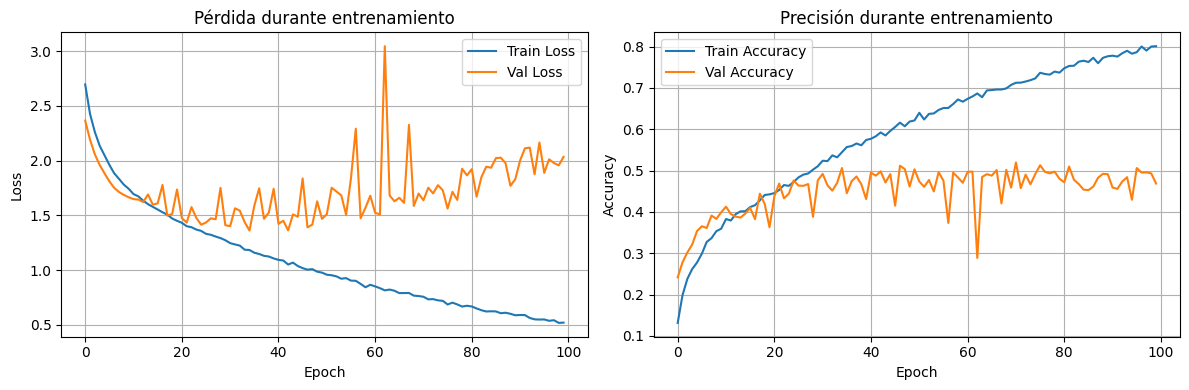

In [61]:
# Evaluación final y reportes
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, le, results):
    # Evaluar en test
    model.eval()
    test_preds = []
    test_true = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            test_preds.extend(outputs.argmax(1).cpu().numpy())
            test_true.extend(batch_y.cpu().numpy())

    test_acc = accuracy_score(test_true, test_preds)
    print(f"Accuracy en test: {test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(test_true, test_preds, target_names=le.classes_))

    # Graficar curvas de pérdida y precisión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(results["train_losses"], label="Train Loss")
    axes[0].plot(results["val_losses"], label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Pérdida durante entrenamiento")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(results["train_accs"], label="Train Accuracy")
    axes[1].plot(results["val_accs"], label="Val Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Precisión durante entrenamiento")
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

evaluate_model(model, test_loader, le, results)


In [62]:
del model

## Simple Inception

In [63]:
class SimpleInceptionTime(nn.Module):
    def __init__(self, in_channels, num_classes, num_inception_modules=3, bottleneck_channels=32):
        super(SimpleInceptionTime, self).__init__()
        
        self.inception_modules = nn.ModuleList()
        # Primer módulo: entrada -> bottleneck
        self.inception_modules.append(InceptionModule(in_channels, bottleneck_channels))
        
        # Siguientes módulos
        for _ in range(num_inception_modules - 1):
            self.inception_modules.append(InceptionModule(bottleneck_channels * 4, bottleneck_channels))
            
        # Novedad: Global Average Pooling (Reduce la longitud de la secuencia a 1)
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # Una sola capa densa (bottleneck_channels * 4 características de salida del inception)
        self.fc = nn.Linear(bottleneck_channels * 4, num_classes)
    
    def forward(self, x):
        # x shape: (batch, sequence_length, features)
        x = x.transpose(1, 2) # (batch, features, sequence_length)
        
        for inception in self.inception_modules:
            # Aquí idealmente iría una conexión residual, pero para 3 capas 
            # este flujo secuencial ya entrenará si usamos GAP.
            x = inception(x)
        
        # Global Average Pooling
        x = self.gap(x) # shape: (batch, channels, 1)
        x = x.squeeze(-1) # shape: (batch, channels)
        
        # Clasificador final
        x = self.fc(x)
        return x
    
# Inicializar modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleInceptionTime(
    in_channels=len(sensor_features),
    num_classes=len(le.classes_),
    num_inception_modules=3,
    bottleneck_channels=32
).to(device)

print(f"Modelo creado en: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")

Modelo creado en: cuda
Parámetros totales: 601,010


In [64]:
results = train_model(model, train_loader, test_loader, num_epochs=50)

Epoch 5/50
  Train Loss: 1.9513, Acc: 0.3904
  Val Loss: 1.9432, Acc: 0.3450
Epoch 10/50
  Train Loss: 1.6334, Acc: 0.4576
  Val Loss: 2.0033, Acc: 0.3770
Epoch 15/50
  Train Loss: 1.4554, Acc: 0.4917
  Val Loss: 1.6669, Acc: 0.4311
Epoch 20/50
  Train Loss: 1.3413, Acc: 0.5229
  Val Loss: 1.6279, Acc: 0.4379
Epoch 25/50
  Train Loss: 1.2558, Acc: 0.5495
  Val Loss: 1.6181, Acc: 0.4250
Epoch 30/50
  Train Loss: 1.1777, Acc: 0.5710
  Val Loss: 1.3803, Acc: 0.4957
Epoch 35/50
  Train Loss: 1.1057, Acc: 0.5900
  Val Loss: 1.6635, Acc: 0.4692
Epoch 40/50
  Train Loss: 1.0457, Acc: 0.6165
  Val Loss: 1.3149, Acc: 0.5289
Epoch 45/50
  Train Loss: 0.9990, Acc: 0.6293
  Val Loss: 2.0294, Acc: 0.3813
Epoch 50/50
  Train Loss: 0.9451, Acc: 0.6476
  Val Loss: 2.5734, Acc: 0.3493

Entrenamiento completado
Mejor accuracy de validación: 0.5289


Accuracy en test: 0.3493

Classification Report:
                                            precision    recall  f1-score   support

                     Above ear - pull hair       0.12      0.99      0.21       125
                        Cheek - pinch skin       0.67      0.02      0.03       117
                     Drink from bottle/cup       1.00      0.76      0.87        34
                       Eyebrow - pull hair       0.00      0.00      0.00       130
                       Eyelash - pull hair       0.00      0.00      0.00       133
Feel around in tray and pull out an object       0.87      1.00      0.93        20
                  Forehead - pull hairline       0.29      0.05      0.09       138
                        Forehead - scratch       0.80      0.03      0.06       121
                            Glasses on/off       1.00      0.79      0.89        39
                         Neck - pinch skin       0.00      0.00      0.00       115
                          

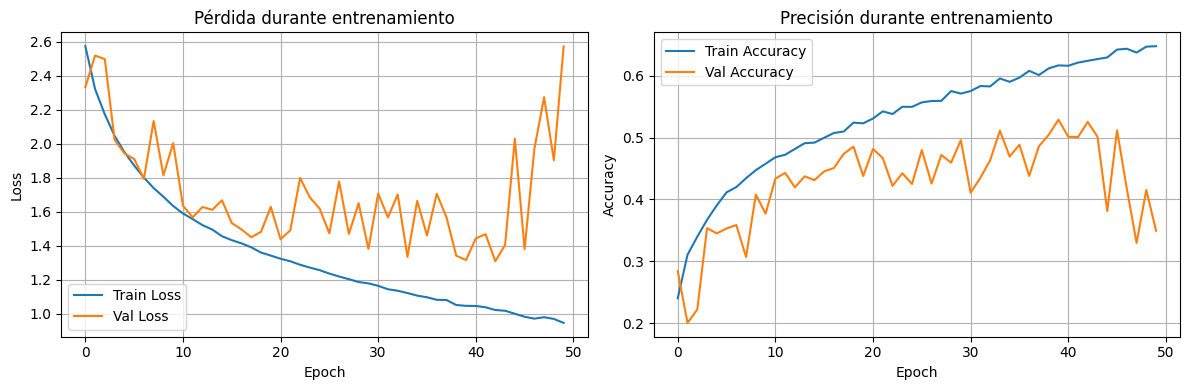

In [65]:
evaluate_model(model, test_loader, le, results)